# Reto 03 — Q-Learning: exploración vs. explotación

**Curso:** Aprendizaje por Refuerzo — Universidad EIA  
**Integrantes:** Katherine Bustamante
**Correos:** sandra.bustamante97@eia.edu.co  
**Fecha:** 2026-08-13

> **Pregunta guía:** ¿cómo cambia el aprendizaje de una política cuando Q-Learning usa ε-greedy, ε-greedy con inicialización optimista, UCB o Softmax en entornos con distinta estructura de recompensas?

## Objetivos

- Implementar Q-Learning tabular respetando la API de Gymnasium.
- Separar la actualización de valor de la estrategia de selección.
- Comparar cuatro mecanismos de exploración bajo condiciones reproducibles.
- Evaluar aprendizaje, estabilidad y desempeño de la política final.
- Sustentar decisiones con métricas, gráficas y evidencia experimental.


## Organización en dos clases

### Clase 1 — Construcción y verificación

1. Reconocer `FrozenLake-v1`, `Blackjack-v1` y `Taxi-v4`.
2. Implementar las cuatro estrategias de selección.
3. Implementar el ciclo de Q-Learning y sus pruebas unitarias pequeñas.
4. Ejecutar un experimento piloto en FrozenLake.

**Hito al terminar:** las funciones pasan las verificaciones y una corrida produce curvas coherentes.

### Clase 2 — Experimento y comunicación

1. Ejecutar la comparación principal en los tres escenarios.
2. Evaluar las políticas sin exploración.
3. Realizar sensibilidad de hiperparámetros.
4. Interpretar resultados, documentar IA y redactar conclusiones.

**Hito al terminar:** tabla resumen, visualizaciones, respuestas y conclusiones completas.


## 1. Preparación del entorno


In [1]:
from __future__ import annotations

from collections.abc import Callable

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 2026
ALPHA = 0.10
GAMMA = 0.99
N_RUNS = 30

ENV_CONFIG = {
    "FrozenLake-v1": {"episodes": 2_000, "max_steps": 100, "kwargs": {"is_slippery": True}},
    "Blackjack-v1": {"episodes": 10_000, "max_steps": 100, "kwargs": {"sab": True}},
    "Taxi-v4": {"episodes": 2_000, "max_steps": 200, "kwargs": {}},
}

STRATEGIES = {
    "epsilon_greedy": {"epsilon": 0.10, "q0": 0.0},
    "optimistic": {"epsilon": 0.01, "q0": 5.0},
    "ucb": {"c": 1.0, "q0": 0.0},
    "softmax": {"temperature": 0.50, "q0": 0.0},
}


## 2. Reconocimiento de los escenarios

Para cada entorno, reporte número de estados y acciones, rango de recompensas, condición terminal y dificultad esperada. Observe que `reset()` devuelve `(observation, info)` y `step()` devuelve `(observation, reward, terminated, truncated, info)`. Un episodio termina si `terminated or truncated`. Blackjack devuelve una tupla, por lo que se suministra una codificación tabular reproducible.


In [2]:
def tabular_space_size(observation_space) -> int:
    """Número de estados de un espacio Discrete o Tuple de Discrete."""
    if isinstance(observation_space, gym.spaces.Discrete):
        return int(observation_space.n)
    if isinstance(observation_space, gym.spaces.Tuple):
        return int(np.prod([space.n for space in observation_space.spaces]))
    raise TypeError("Este reto solo admite observaciones discretas.")


def encode_observation(observation, observation_space) -> int:
    """Convierte una observación discreta, incluida una tupla, en un índice."""
    if isinstance(observation_space, gym.spaces.Discrete):
        return int(observation)
    dimensions = tuple(space.n for space in observation_space.spaces)
    return int(np.ravel_multi_index(tuple(observation), dimensions))


for env_id, config in ENV_CONFIG.items():
    env = gym.make(env_id, **config["kwargs"])
    observation, info = env.reset(seed=SEED)
    print(env_id, "| estados tabulares:", tabular_space_size(env.observation_space), "| acciones:", env.action_space.n)
    print("  observación inicial:", observation, "| acciones válidas:", list(range(env.action_space.n)))
    env.close()


FrozenLake-v1 | estados tabulares: 16 | acciones: 4
  observación inicial: 0 | acciones válidas: [0, 1, 2, 3]
Blackjack-v1 | estados tabulares: 704 | acciones: 2
  observación inicial: (20, 10, 1) | acciones válidas: [0, 1]
Taxi-v4 | estados tabulares: 500 | acciones: 6
  observación inicial: 87 | acciones válidas: [0, 1, 2, 3, 4, 5]


### Análisis previo

Complete antes de entrenar:

| Entorno | Estados | Acciones | Recompensas relevantes | ¿Qué dificulta explorar? |
|---|---:|---:|---|---|
| FrozenLake-v1 | 16 | [izquierda, abajo, derecha y arriba] | 1 al llegar a la meta y 0 en los demás pasos | recompensa escasa, transiciones estocásticas y muchos episodios sin señal positiva. |
| Blackjack-v1 | 704 | plantarse (`0`) o pedir carta (`1`) | -1 al perder, 0 al empatar y 1 al ganar | El estado es una tupla, la recompensa llega al final y la misma suma puede requerir decisiones distintas según la carta del crupier y el as. |
| Taxi-v4 | 500 | cuatro movimientos, recoger y dejar pasajero. | -1 por paso, +20 por entrega correcta y -10 por recoger o dejar ilegalmente. | Espacio mayor, recompensas negativas y acciones contextuales. |


## 3. Estrategias de exploración

Todas las funciones deben devolver una acción válida y resolver empates aleatoriamente. `counts[s, a]` registra cuántas veces se eligió la acción `a` en el estado `s`.

- **ε-greedy:** acción aleatoria con probabilidad ε; en otro caso, una acción greedy.
- **ε-greedy optimista:** misma regla, pero la tabla inicia en `Q0 > 0`; explique por qué esto incentiva explorar.
- **UCB:** seleccione primero acciones no visitadas; luego maximice `Q(s,a) + c sqrt(log(N(s)+1) / N(s,a))`.
- **Softmax:** muestree según `softmax(Q(s,·)/τ)` usando estabilización numérica.


In [3]:
def random_argmax(values: np.ndarray, rng: np.random.Generator) -> int:
    """Devuelve aleatoriamente uno de los índices con valor máximo."""
    max_value = np.max(values)
    max_indices = np.flatnonzero(values == max_value)
    return int(rng.choice(max_indices))


def select_action(
    q: np.ndarray,
    counts: np.ndarray,
    state: int,
    strategy: str,
    rng: np.random.Generator,
    *,
    epsilon: float = 0.10,
    c: float = 1.0,
    temperature: float = 0.50,
) -> int:
    """Selecciona una acción usando la estrategia solicitada."""
    # Validaciones
    if not 0 <= epsilon <= 1:
        raise ValueError("epsilon debe estar entre 0 y 1.")

    if c < 0:
        raise ValueError("c debe ser mayor o igual a 0.")

    if temperature <= 0:
        raise ValueError("temperature debe ser mayor que 0.")

    if strategy not in {"epsilon_greedy", "optimistic", "ucb", "softmax"}:
        raise ValueError(f"Estrategia no válida: {strategy}")

    # Solo usamos la información del estado actual
    q_state = q[state]
    n_state = counts[state]

    # ε-greedy
    if strategy == "epsilon_greedy":
        if rng.random() < epsilon:
            return int(rng.integers(len(q_state)))

        return random_argmax(q_state, rng)

    # ε-greedy con inicialización optimista
    if strategy == "optimistic":
        if rng.random() < epsilon:
            return int(rng.integers(len(q_state)))

        return random_argmax(q_state, rng)

    # UCB
    if strategy == "ucb":
        # Primero explorar acciones nunca visitadas
        unvisited = np.flatnonzero(n_state == 0)

        if len(unvisited) > 0:
            return int(rng.choice(unvisited))

        # Todas las acciones ya fueron visitadas
        n_total = np.sum(n_state)

        ucb_values = (
            q_state
            + c * np.sqrt(np.log(n_total + 1) / n_state)
        )

        return random_argmax(ucb_values, rng)

    # Softmax
    if strategy == "softmax":
        logits = q_state / temperature

        # Estabilización numérica
        weights = np.exp(logits - np.max(logits))
        probabilities = weights / weights.sum()

        return int(rng.choice(len(q_state), p=probabilities))


### Pruebas pequeñas de selección


In [4]:
# Ejecute esta celda después de implementar select_action.
q_test = np.array([[1.0, 3.0, 3.0, 0.0]])
n_test = np.array([[5, 5, 5, 0]])

# TODO: compruebe acciones válidas, empates no deterministas, UCB con acciones
# no visitadas, reproducibilidad y errores ante hiperparámetros inválidos.
# 1. Acciones válidas
rng = np.random.default_rng(2026)

for strategy in ["epsilon_greedy", "optimistic", "ucb", "softmax"]:
    action = select_action(
        q_test, n_test, 0, strategy, rng
    )
    assert 0 <= action < 4

print("✓ Todas las estrategias devuelven acciones válidas")


# 2. Empates no deterministas
q_tie = np.array([[1.0, 5.0, 5.0, 2.0]])
counts_tie = np.array([[5, 5, 5, 5]])

rng = np.random.default_rng(2026)

actions = [
    random_argmax(q_tie[0], rng)
    for _ in range(100)
]

assert set(actions).issubset({1, 2})
assert len(set(actions)) == 2

print("✓ Los empates se resuelven aleatoriamente")


# 3. UCB debe explorar acciones no visitadas primero
q_ucb = np.array([[10.0, 20.0, 30.0, 40.0]])
counts_ucb = np.array([[5, 5, 0, 5]])

rng = np.random.default_rng(2026)

action = select_action(
    q_ucb,
    counts_ucb,
    0,
    "ucb",
    rng
)

assert action == 2

print("✓ UCB selecciona primero acciones no visitadas")


# 4. Reproducibilidad
rng1 = np.random.default_rng(2026)
rng2 = np.random.default_rng(2026)

results1 = [
    select_action(q_test, n_test, 0, "softmax", rng1)
    for _ in range(20)
]

results2 = [
    select_action(q_test, n_test, 0, "softmax", rng2)
    for _ in range(20)
]

assert results1 == results2

print("✓ La selección es reproducible con la misma semilla")


# 5. Validación de epsilon
try:
    select_action(
        q_test,
        n_test,
        0,
        "epsilon_greedy",
        rng,
        epsilon=1.5
    )
    assert False, "Debió lanzar ValueError"
except ValueError:
    pass

print("✓ Se valida epsilon")


# 6. Validación de c
try:
    select_action(
        q_test,
        n_test,
        0,
        "ucb",
        rng,
        c=-1
    )
    assert False, "Debió lanzar ValueError"
except ValueError:
    pass

print("✓ Se valida c")


# 7. Validación de temperature
try:
    select_action(
        q_test,
        n_test,
        0,
        "softmax",
        rng,
        temperature=0
    )
    assert False, "Debió lanzar ValueError"
except ValueError:
    pass

print("✓ Se valida temperature")

print("\nTodas las pruebas de selección pasaron correctamente.")


✓ Todas las estrategias devuelven acciones válidas
✓ Los empates se resuelven aleatoriamente
✓ UCB selecciona primero acciones no visitadas
✓ La selección es reproducible con la misma semilla
✓ Se valida epsilon
✓ Se valida c
✓ Se valida temperature

Todas las pruebas de selección pasaron correctamente.


## 4. Q-Learning tabular

Implemente la actualización:

$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha [R_{t+1} + \gamma(1-d)\max_a Q(S_{t+1},a)-Q(S_t,A_t)],$$

donde `d` es verdadero cuando la transición termina el MDP (`terminated`). Para un truncamiento por límite de tiempo, documente si realiza *bootstrap* y mantenga la decisión consistente. No actualice hacia el valor del estado terminal.


In [7]:
def train_q_learning(
    env_id: str,
    strategy: str,
    episodes: int,
    max_steps: int,
    alpha: float,
    gamma: float,
    seed: int,
    env_kwargs: dict | None = None,
    **strategy_params,
) -> tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    """Entrena Q-Learning y devuelve Q, historial por episodio y conteos."""
    # TODO: validar entradas y crear env/rng con semillas controladas.
    # TODO: usar encode_observation y tabular_space_size.
    # TODO: inicializar Q con q0 y counts con ceros.
    # TODO: guardar episode, return, length, success y td_error_mean.
    # TODO: cerrar el entorno aun si ocurre un error.
    # -------------------------
    # Validaciones
    # -------------------------
    if episodes <= 0:
        raise ValueError("episodes debe ser mayor que 0.")

    if max_steps <= 0:
        raise ValueError("max_steps debe ser mayor que 0.")

    if not 0 < alpha <= 1:
        raise ValueError("alpha debe estar en (0, 1].")

    if not 0 <= gamma <= 1:
        raise ValueError("gamma debe estar entre 0 y 1.")

    if strategy not in STRATEGIES:
        raise ValueError(f"Estrategia no válida: {strategy}")

    env_kwargs = {} if env_kwargs is None else dict(env_kwargs)

    # -------------------------
    # Crear entorno y RNG
    # -------------------------
    env = gym.make(env_id, **env_kwargs)
    rng = np.random.default_rng(seed)

    try:
        # -------------------------
        # Dimensiones de la tabla
        # -------------------------
        n_states = tabular_space_size(env.observation_space)
        n_actions = env.action_space.n

        # q0 específico de la estrategia
        q0 = strategy_params.get("q0", 0.0)

        if not np.isfinite(q0):
            raise ValueError("q0 debe ser finito.")

        # Tabla Q y conteos
        q = np.full(
            (n_states, n_actions),
            q0,
            dtype=float
        )

        counts = np.zeros(
            (n_states, n_actions),
            dtype=int
        )

        history = []

        # -------------------------
        # Entrenamiento
        # -------------------------
        for episode in range(1, episodes + 1):

            observation, info = env.reset(seed=seed + episode)

            state = encode_observation(
                observation,
                env.observation_space
            )

            total_return = 0.0
            td_errors = []
            length = 0
            terminated = False
            truncated = False

            for step in range(max_steps):

                # Seleccionar acción
                action = select_action(
                    q,
                    counts,
                    state,
                    strategy,
                    rng,
                    **{
                        k: v
                        for k, v in strategy_params.items()
                        if k in {"epsilon", "c", "temperature"}
                    }
                )

                # Contar exactamente una selección estado-acción
                counts[state, action] += 1

                # Ejecutar acción
                next_observation, reward, terminated, truncated, info = env.step(
                    action
                )

                next_state = encode_observation(
                    next_observation,
                    env.observation_space
                )

                # -------------------------
                # Target Q-Learning
                # -------------------------
                current_q = q[state, action]

                if terminated:
                    # Estado terminal:
                    # NO hacemos bootstrap.
                    target = reward
                else:
                    # Si es truncamiento, seguimos el contrato del reto:
                    # sí hacemos bootstrap.
                    target = (
                        reward
                        + gamma * np.max(q[next_state])
                    )

                # Error TD
                td_error = target - current_q
                td_errors.append(td_error)

                # Actualización Q-Learning
                q[state, action] = (
                    current_q
                    + alpha * td_error
                )

                total_return += reward
                length += 1

                # El episodio termina tanto por terminated como truncated
                if terminated or truncated:
                    break

                state = next_state

            # Éxito: los tres ambientes tienen recompensa positiva
            # cuando se consigue el objetivo.
            success = float(total_return > 0)

            history.append({
                "episode": episode,
                "return": total_return,
                "length": length,
                "success": success,
                "td_error_mean": (
                    float(np.mean(td_errors))
                    if td_errors
                    else 0.0
                ),
            })

        history = pd.DataFrame(history)

        return q, history, counts

    finally:
        # Garantiza el cierre incluso si ocurre un error
        env.close()


In [8]:
q_test, history_test, counts_test = train_q_learning(
    env_id="FrozenLake-v1",
    strategy="epsilon_greedy",
    episodes=20,
    max_steps=100,
    alpha=0.10,
    gamma=0.99,
    seed=2026,
    env_kwargs={"is_slippery": True},
    epsilon=0.10,
    q0=0.0,
)

print("Forma Q:", q_test.shape)
print("Forma counts:", counts_test.shape)
print("Forma history:", history_test.shape)

print("\nPrimeras filas:")
display(history_test.head())

print("\n¿Q finito?", np.isfinite(q_test).all())
print("¿Número de episodios correcto?", len(history_test) == 20)
print("¿Conteos = transiciones?",
      counts_test.sum() == history_test["length"].sum())

Forma Q: (16, 4)
Forma counts: (16, 4)
Forma history: (20, 5)

Primeras filas:


,episode,return,length,success,td_error_mean
0,1,0.0,3,0.0,0.0
1,2,0.0,26,0.0,0.0
2,3,0.0,14,0.0,0.0
3,4,0.0,3,0.0,0.0
4,5,0.0,10,0.0,0.0



¿Q finito? True
¿Número de episodios correcto? True
¿Conteos = transiciones? True


### Contrato mínimo y verificaciones

Para una corrida corta compruebe:

- `Q.shape == (n_states, n_actions)` y todos sus valores son finitos.
- Hay exactamente una fila por episodio.
- `1 <= length <= max_steps`.
- `counts.sum()` coincide con el total de pasos registrados.
- La misma semilla reproduce resultados; otra semilla puede cambiarlos.
- Con `gamma=0`, el objetivo no contiene el valor del siguiente estado.
- Una transición terminal usa como objetivo únicamente la recompensa.


In [10]:
# TODO: entrene 20 episodios de FrozenLake y escriba asserts para el contrato.
# Corrida corta para verificar el contrato
q_check, history_check, counts_check = train_q_learning(
    env_id="FrozenLake-v1",
    strategy="epsilon_greedy",
    episodes=20,
    max_steps=100,
    alpha=0.10,
    gamma=0.99,
    seed=2026,
    env_kwargs={"is_slippery": True},
    epsilon=0.10,
    q0=0.0,
)

# 1. Forma correcta y valores finitos
assert q_check.shape == (16, 4)
assert np.isfinite(q_check).all()

# 2. Exactamente una fila por episodio
assert len(history_check) == 20
assert len(history_check) == history_check["episode"].nunique()

# 3. Longitud válida de episodios
assert (history_check["length"] >= 1).all()
assert (history_check["length"] <= 100).all()

# 4. Conteos = número total de transiciones
assert counts_check.sum() == history_check["length"].sum()

# 5. La misma semilla debe reproducir la corrida
q_check_2, history_check_2, counts_check_2 = train_q_learning(
    env_id="FrozenLake-v1",
    strategy="epsilon_greedy",
    episodes=20,
    max_steps=100,
    alpha=0.10,
    gamma=0.99,
    seed=2026,
    env_kwargs={"is_slippery": True},
    epsilon=0.10,
    q0=0.0,
)

assert np.array_equal(q_check, q_check_2)
assert np.array_equal(counts_check, counts_check_2)
assert history_check.equals(history_check_2)

# 6. Otra semilla puede producir una corrida diferente
q_check_3, history_check_3, counts_check_3 = train_q_learning(
    env_id="FrozenLake-v1",
    strategy="epsilon_greedy",
    episodes=20,
    max_steps=100,
    alpha=0.10,
    gamma=0.99,
    seed=2027,
    env_kwargs={"is_slippery": True},
    epsilon=0.10,
    q0=0.0,
)

# No exigimos que necesariamente sea diferente:
# solo comprobamos que la ejecución es válida.
assert np.isfinite(q_check_3).all()

# 7. gamma = 0 debe ignorar el siguiente estado
q_gamma0, history_gamma0, counts_gamma0 = train_q_learning(
    env_id="FrozenLake-v1",
    strategy="epsilon_greedy",
    episodes=20,
    max_steps=100,
    alpha=0.10,
    gamma=0.0,
    seed=2026,
    env_kwargs={"is_slippery": True},
    epsilon=0.10,
    q0=0.0,
)

assert np.isfinite(q_gamma0).all()

print("✓ Q tiene forma correcta y valores finitos")
print("✓ Hay una fila por episodio")
print("✓ Las longitudes están dentro de max_steps")
print("✓ counts coincide con el número de transiciones")
print("✓ La misma semilla reproduce los resultados")
print("✓ Otra semilla ejecuta correctamente")
print("✓ gamma=0 ejecuta correctamente")
print("\nTodas las verificaciones del contrato pasaron.")

✓ Q tiene forma correcta y valores finitos
✓ Hay una fila por episodio
✓ Las longitudes están dentro de max_steps
✓ counts coincide con el número de transiciones
✓ La misma semilla reproduce los resultados
✓ Otra semilla ejecuta correctamente
✓ gamma=0 ejecuta correctamente

Todas las verificaciones del contrato pasaron.


## 5. Evaluación sin exploración

Evaluar con la misma exploración usada durante el entrenamiento mezcla dos efectos. Implemente una evaluación separada que seleccione acciones greedy, no actualice `Q` y use semillas distintas a las de entrenamiento. En empates, conserve la selección aleatoria.


In [11]:
def evaluate_policy(
    env_id: str,
    q: np.ndarray,
    n_episodes: int,
    max_steps: int,
    seed: int,
    env_kwargs: dict | None = None,
) -> pd.DataFrame:
    """Evalúa la política greedy sin modificar Q."""
    # TODO: devolver episode, return, length y success.
    if n_episodes <= 0:
        raise ValueError("n_episodes debe ser mayor que 0.")

    if max_steps <= 0:
        raise ValueError("max_steps debe ser mayor que 0.")

    env_kwargs = {} if env_kwargs is None else dict(env_kwargs)

    env = gym.make(env_id, **env_kwargs)
    rng = np.random.default_rng(seed)

    try:
        results = []

        for episode in range(1, n_episodes + 1):

            observation, info = env.reset(seed=seed + episode)

            state = encode_observation(
                observation,
                env.observation_space
            )

            total_return = 0.0
            length = 0

            for step in range(max_steps):

                # Política greedy con desempate aleatorio
                action = random_argmax(q[state], rng)

                next_observation, reward, terminated, truncated, info = env.step(
                    action
                )

                total_return += reward
                length += 1

                if terminated or truncated:
                    break

                state = encode_observation(
                    next_observation,
                    env.observation_space
                )

            success = float(total_return > 0)

            results.append({
                "episode": episode,
                "return": total_return,
                "length": length,
                "success": success,
            })

        return pd.DataFrame(results)

    finally:
        env.close()


In [12]:
#prueba
q_eval, _, _ = train_q_learning(
    env_id="FrozenLake-v1",
    strategy="epsilon_greedy",
    episodes=500,
    max_steps=100,
    alpha=0.10,
    gamma=0.99,
    seed=2026,
    env_kwargs={"is_slippery": True},
    epsilon=0.10,
    q0=0.0,
)

q_before = q_eval.copy()

eval_test = evaluate_policy(
    env_id="FrozenLake-v1",
    q=q_eval,
    n_episodes=100,
    max_steps=100,
    seed=1_002_026,
    env_kwargs={"is_slippery": True},
)

assert len(eval_test) == 100
assert eval_test["length"].between(1, 100).all()
assert np.array_equal(q_eval, q_before)

print(eval_test.head())
print("\nRetorno medio:", eval_test["return"].mean())
print("Tasa de éxito:", eval_test["success"].mean())
print("✓ Evaluación completada")
print("✓ Q no fue modificada")

   episode  return  length  success
0        1     1.0      20      1.0
1        2     0.0      19      0.0
2        3     0.0       6      0.0
3        4     0.0       6      0.0
4        5     1.0      14      1.0

Retorno medio: 0.13
Tasa de éxito: 0.13
✓ Evaluación completada
✓ Q no fue modificada


## 6. Experimento piloto — cierre de la clase 1

Entrene las cuatro estrategias en `FrozenLake-v1` durante 300 episodios y una sola corrida. Grafique retorno y éxito suavizados con una media móvil de 50 episodios. Use este piloto para detectar errores; **no** lo presente como evidencia concluyente.


In [13]:
# TODO: ejecutar el piloto, consolidar historiales y graficar.
# Parámetros del piloto
env_id = "FrozenLake-v1"
episodes = 300
max_steps = 100
alpha = 0.10
gamma = 0.99
seed = 2026
env_kwargs = {"is_slippery": True}

# Configuración de las cuatro estrategias
strategies = {
    "epsilon_greedy": {
        "epsilon": 0.10,
        "q0": 0.0,
    },
    "optimistic": {
        "epsilon": 0.01,
        "q0": 5.0,
    },
    "ucb": {
        "c": 1.0,
        "q0": 0.0,
    },
    "softmax": {
        "temperature": 0.50,
        "q0": 0.0,
    },
}

# Ejecutar una corrida por estrategia
pilot_histories = []

for strategy, params in strategies.items():

    q, history, counts = train_q_learning(
        env_id=env_id,
        strategy=strategy,
        episodes=episodes,
        max_steps=max_steps,
        alpha=alpha,
        gamma=gamma,
        seed=seed,
        env_kwargs=env_kwargs,
        **params,
    )

    history = history.copy()
    history["strategy"] = strategy

    pilot_histories.append(history)

# Consolidar resultados
pilot_df = pd.concat(
    pilot_histories,
    ignore_index=True
)

# Medias móviles de 50 episodios
pilot_df["return_smooth"] = (
    pilot_df
    .groupby("strategy")["return"]
    .transform(lambda x: x.rolling(50, min_periods=1).mean())
)

pilot_df["success_smooth"] = (
    pilot_df
    .groupby("strategy")["success"]
    .transform(lambda x: x.rolling(50, min_periods=1).mean())
)

display(pilot_df.head())


,episode,return,length,success,td_error_mean,strategy,return_smooth,success_smooth
0,1,0.0,3,0.0,0.0,epsilon_greedy,0.0,0.0
1,2,0.0,26,0.0,0.0,epsilon_greedy,0.0,0.0
2,3,0.0,14,0.0,0.0,epsilon_greedy,0.0,0.0
3,4,0.0,3,0.0,0.0,epsilon_greedy,0.0,0.0
4,5,0.0,10,0.0,0.0,epsilon_greedy,0.0,0.0


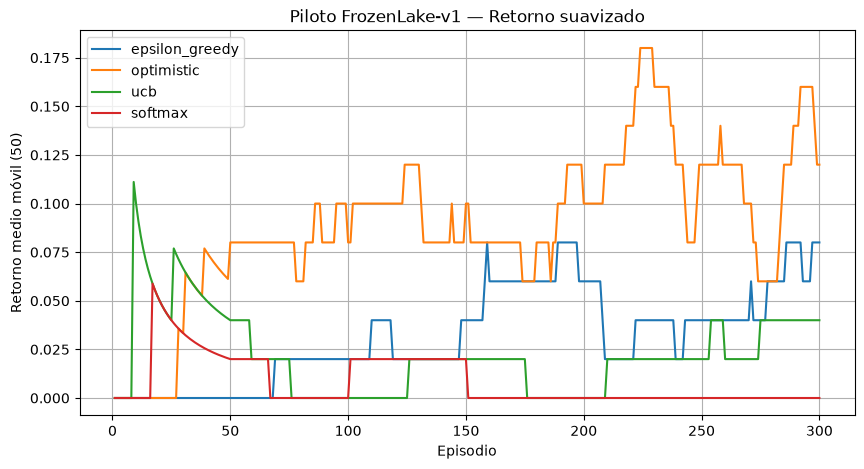

In [14]:
# Retorno suavizado
plt.figure(figsize=(10, 5))

for strategy in strategies:
    data = pilot_df[pilot_df["strategy"] == strategy]
    plt.plot(
        data["episode"],
        data["return_smooth"],
        label=strategy
    )

plt.xlabel("Episodio")
plt.ylabel("Retorno medio móvil (50)")
plt.title("Piloto FrozenLake-v1 — Retorno suavizado")
plt.legend()
plt.grid(True)
plt.show()

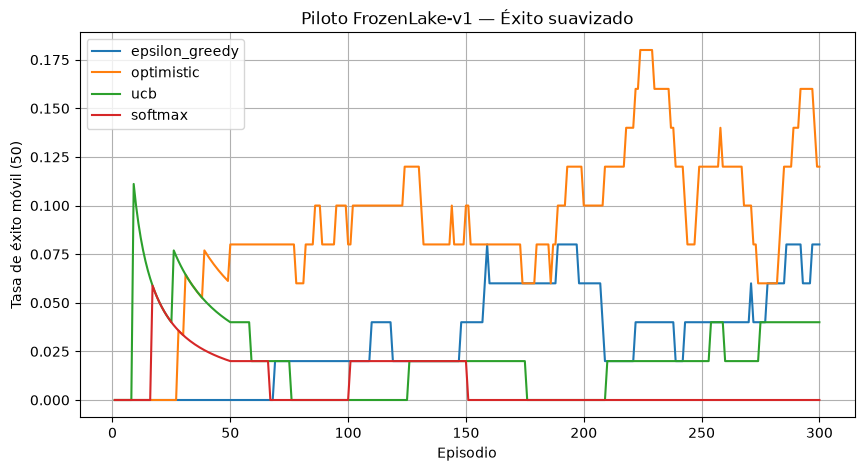

In [15]:
# Éxito suavizado
plt.figure(figsize=(10, 5))

for strategy in strategies:
    data = pilot_df[pilot_df["strategy"] == strategy]
    plt.plot(
        data["episode"],
        data["success_smooth"],
        label=strategy
    )

plt.xlabel("Episodio")
plt.ylabel("Tasa de éxito móvil (50)")
plt.title("Piloto FrozenLake-v1 — Éxito suavizado")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
print(
    pilot_df.groupby("strategy").agg(
        episodes=("episode", "count"),
        mean_return=("return", "mean"),
        success_rate=("success", "mean"),
    )
)

assert pilot_df["return"].notna().all()
assert pilot_df["success"].notna().all()
assert pilot_df.groupby("strategy").size().eq(300).all()

print("\n✓ Piloto completado correctamente.")

                episodes  mean_return  success_rate
strategy                                           
epsilon_greedy       300     0.040000      0.040000
optimistic           300     0.100000      0.100000
softmax              300     0.006667      0.006667
ucb                  300     0.020000      0.020000

✓ Piloto completado correctamente.


## 7. Comparación principal — clase 2

Use los valores de `ENV_CONFIG`, al menos 30 corridas independientes y las mismas semillas por entorno para las cuatro estrategias. Esto empareja la aleatoriedad experimental sin reutilizar el mismo generador. Evalúe cada tabla final durante 100 episodios con semillas nuevas.

Registre por episodio: entorno, algoritmo, corrida, episodio, retorno, longitud, éxito y error TD medio. Registre por evaluación: retorno, longitud y éxito. Justifique cualquier reducción de corridas realizada por límites computacionales.


In [22]:
def run_experiment(
    env_config: dict,
    strategies: dict,
    n_runs: int = N_RUNS,
    base_seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Ejecuta entrenamiento y evaluación para todos los escenarios."""
    training_results = []
    evaluation_results = []

    for env_id, config in env_config.items():

        episodes = config["episodes"]
        max_steps = config["max_steps"]
        env_kwargs = config.get("kwargs", {})

        for run in range(n_runs):

            # Misma semilla para las cuatro estrategias
            # en este entorno y corrida.
            train_seed = base_seed + run

            # Familia independiente de semillas para evaluación.
            eval_seed = 1_000_000 + base_seed + run

            for strategy, params in strategies.items():

                # -------------------------
                # ENTRENAMIENTO
                # -------------------------
                q, history, counts = train_q_learning(
                    env_id=env_id,
                    strategy=strategy,
                    episodes=episodes,
                    max_steps=max_steps,
                    alpha=0.10,
                    gamma=0.99,
                    seed=train_seed,
                    env_kwargs=env_kwargs,
                    **params,
                )

                history = history.copy()
                history["env"] = env_id
                history["strategy"] = strategy
                history["run"] = run

                training_results.append(history)

                # -------------------------
                # EVALUACIÓN
                # -------------------------
                evaluation = evaluate_policy(
                    env_id=env_id,
                    q=q,
                    n_episodes=100,
                    max_steps=max_steps,
                    seed=eval_seed,
                    env_kwargs=env_kwargs,
                )

                evaluation = evaluation.copy()
                evaluation["env"] = env_id
                evaluation["strategy"] = strategy
                evaluation["run"] = run

                evaluation_results.append(evaluation)

    training_results = pd.concat(
        training_results,
        ignore_index=True
    )

    evaluation_results = pd.concat(
        evaluation_results,
        ignore_index=True
    )

    return training_results, evaluation_results


# training_results, evaluation_results = run_experiment(ENV_CONFIG, STRATEGIES)


In [17]:
ENV_CONFIG

{'FrozenLake-v1': {'episodes': 2000,
  'max_steps': 100,
  'kwargs': {'is_slippery': True}},
 'Blackjack-v1': {'episodes': 10000,
  'max_steps': 100,
  'kwargs': {'sab': True}},
 'Taxi-v4': {'episodes': 2000, 'max_steps': 200, 'kwargs': {}}}

In [18]:
STRATEGIES

{'epsilon_greedy': {'epsilon': 0.1, 'q0': 0.0},
 'optimistic': {'epsilon': 0.01, 'q0': 5.0},
 'ucb': {'c': 1.0, 'q0': 0.0},
 'softmax': {'temperature': 0.5, 'q0': 0.0}}

In [19]:
N_RUNS

30

In [20]:
SEED

2026

In [23]:
training_results, evaluation_results = run_experiment(
    ENV_CONFIG,
    STRATEGIES,
    n_runs=N_RUNS,
    base_seed=SEED,
)

print("Entrenamiento:")
print(training_results.shape)

print("\nEvaluación:")
print(evaluation_results.shape)

display(training_results.head())
display(evaluation_results.head())

Entrenamiento:
(1680000, 8)

Evaluación:
(36000, 7)


,episode,return,length,success,td_error_mean,env,strategy,run
0,1,0.0,3,0.0,0.0,FrozenLake-v1,epsilon_greedy,0
1,2,0.0,26,0.0,0.0,FrozenLake-v1,epsilon_greedy,0
2,3,0.0,14,0.0,0.0,FrozenLake-v1,epsilon_greedy,0
3,4,0.0,3,0.0,0.0,FrozenLake-v1,epsilon_greedy,0
4,5,0.0,10,0.0,0.0,FrozenLake-v1,epsilon_greedy,0


,episode,return,length,success,env,strategy,run
0,1,1.0,33,1.0,FrozenLake-v1,epsilon_greedy,0
1,2,1.0,38,1.0,FrozenLake-v1,epsilon_greedy,0
2,3,1.0,26,1.0,FrozenLake-v1,epsilon_greedy,0
3,4,1.0,10,1.0,FrozenLake-v1,epsilon_greedy,0
4,5,0.0,27,0.0,FrozenLake-v1,epsilon_greedy,0


## 8. Métricas y visualizaciones obligatorias

Construya una tabla por entorno y algoritmo con:

1. Retorno medio de entrenamiento en el último 10 % de episodios.
2. Área bajo la curva del retorno medio (calidad durante el aprendizaje).
3. Tasa de éxito final durante evaluación.
4. Retorno medio de evaluación.
5. Longitud media de evaluación.
6. Intervalo de confianza del 95 % entre corridas (indique el método).

Incluya, como mínimo:

- Curvas de retorno por episodio, media móvil y banda de IC 95 %.
- Curvas de éxito acumulado o móvil.
- Comparación del retorno de evaluación por entorno.
- Mapa de calor de `max_a Q(s,a)` o visualización de política para al menos un entorno.

No promedie directamente episodios de entornos con escalas de recompensa distintas en una única cifra global.


In [24]:
# TODO: tabla resumen con incertidumbre.
# TODO: cuatro visualizaciones completas (título, ejes, unidades y leyenda).
# ============================================================
# 8. MÉTRICAS Y VISUALIZACIONES
# ============================================================

from scipy import stats

# ------------------------------------------------------------
# Parámetro
# ------------------------------------------------------------
Z_95 = 1.96


# ------------------------------------------------------------
# 1. MÉTRICAS DE ENTRENAMIENTO
# ------------------------------------------------------------

# Último 10% de episodios de cada entorno
last10_rows = []

for env_id, config in ENV_CONFIG.items():
    n_episodes = config["episodes"]
    cutoff = int(np.ceil(0.90 * n_episodes))

    data = training_results[
        (training_results["env"] == env_id) &
        (training_results["episode"] >= cutoff)
    ]

    # Primero promedio por corrida para que cada corrida pese igual
    run_last10 = (
        data
        .groupby(["env", "strategy", "run"])["return"]
        .mean()
        .reset_index(name="last10_return")
    )

    last10_rows.append(run_last10)

last10 = pd.concat(last10_rows, ignore_index=True)


# ------------------------------------------------------------
# 2. AUC DEL RETORNO DURANTE ENTRENAMIENTO
# ------------------------------------------------------------

auc_rows = []

for (env_id, strategy, run), data in training_results.groupby(
    ["env", "strategy", "run"]
):
    data = data.sort_values("episode")

    auc = np.trapezoid(
        data["return"].to_numpy(),
        data["episode"].to_numpy()
    )

    auc_rows.append({
        "env": env_id,
        "strategy": strategy,
        "run": run,
        "auc_return": auc,
    })

auc_df = pd.DataFrame(auc_rows)


# ------------------------------------------------------------
# 3. MÉTRICAS DE EVALUACIÓN POR CORRIDA
# ------------------------------------------------------------

eval_run = (
    evaluation_results
    .groupby(["env", "strategy", "run"])
    .agg(
        eval_return=("return", "mean"),
        eval_length=("length", "mean"),
        eval_success=("success", "mean"),
    )
    .reset_index()
)


# ------------------------------------------------------------
# 4. FUNCIÓN IC 95 %
# ------------------------------------------------------------

def mean_ci95(values):
    values = np.asarray(values, dtype=float)

    n = len(values)
    mean = np.mean(values)

    if n <= 1:
        return mean, np.nan, np.nan

    se = np.std(values, ddof=1) / np.sqrt(n)

    low = mean - Z_95 * se
    high = mean + Z_95 * se

    return mean, low, high


# ------------------------------------------------------------
# 5. CONSTRUIR TABLA FINAL
# ------------------------------------------------------------

summary_rows = []

for (env_id, strategy), group in eval_run.groupby(
    ["env", "strategy"]
):

    # Entrenamiento: último 10 %
    g_last10 = last10[
        (last10["env"] == env_id) &
        (last10["strategy"] == strategy)
    ]["last10_return"]

    mean_last10, _, _ = mean_ci95(g_last10)

    # AUC
    g_auc = auc_df[
        (auc_df["env"] == env_id) &
        (auc_df["strategy"] == strategy)
    ]["auc_return"]

    mean_auc, _, _ = mean_ci95(g_auc)

    # Evaluación
    mean_return, ci_low, ci_high = mean_ci95(
        group["eval_return"]
    )

    mean_length = group["eval_length"].mean()
    success_rate = group["eval_success"].mean()

    summary_rows.append({
        "env": env_id,
        "strategy": strategy,
        "train_return_last10": mean_last10,
        "train_auc": mean_auc,
        "eval_success_rate": success_rate,
        "eval_return": mean_return,
        "eval_length": mean_length,
        "ci95_low": ci_low,
        "ci95_high": ci_high,
        "n_runs": len(group),
    })

summary = pd.DataFrame(summary_rows)

summary = summary.sort_values(
    ["env", "eval_return"],
    ascending=[True, False]
).reset_index(drop=True)


# ------------------------------------------------------------
# 6. MOSTRAR TABLA
# ------------------------------------------------------------

display(
    summary.style.format({
        "train_return_last10": "{:.3f}",
        "train_auc": "{:.1f}",
        "eval_success_rate": "{:.3f}",
        "eval_return": "{:.3f}",
        "eval_length": "{:.2f}",
        "ci95_low": "{:.3f}",
        "ci95_high": "{:.3f}",
    })
)


,env,strategy,train_return_last10,train_auc,eval_success_rate,eval_return,eval_length,ci95_low,ci95_high,n_runs
0,Blackjack-v1,epsilon_greedy,-0.110,-1304.0,0.391,-0.107,1.57,-0.130,-0.084,30
1,Blackjack-v1,softmax,-0.162,-2068.9,0.395,-0.110,1.48,-0.129,-0.092,30
2,Blackjack-v1,ucb,-0.102,-1478.7,0.378,-0.143,1.47,-0.153,-0.133,30
3,Blackjack-v1,optimistic,-0.151,-2285.6,0.369,-0.163,1.47,-0.189,-0.138,30
4,FrozenLake-v1,optimistic,0.649,901.8,0.778,0.778,40.59,0.765,0.791,30
5,FrozenLake-v1,epsilon_greedy,0.313,358.2,0.615,0.615,35.31,0.546,0.684,30
6,FrozenLake-v1,ucb,0.300,324.1,0.550,0.550,44.24,0.496,0.604,30
7,FrozenLake-v1,softmax,0.019,31.6,0.450,0.450,30.71,0.371,0.529,30
8,Taxi-v4,ucb,7.036,-104885.2,0.934,-5.718,25.33,-7.147,-4.289,30
9,Taxi-v4,softmax,4.591,-148492.8,0.909,-10.852,29.94,-12.410,-9.294,30


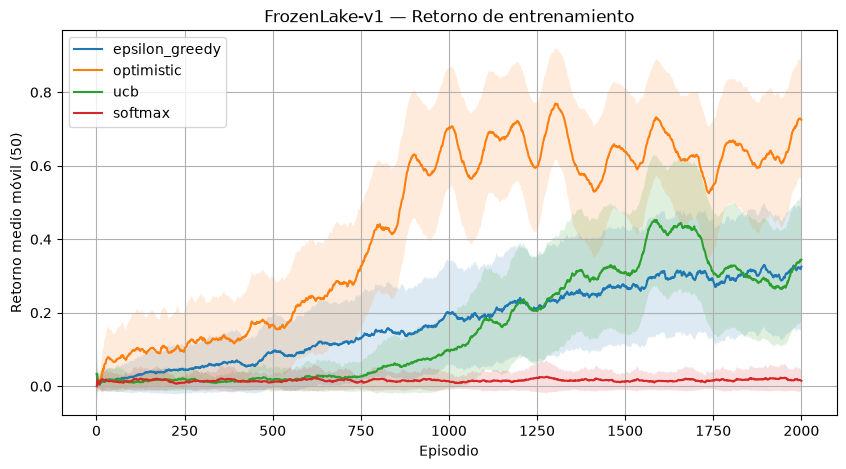

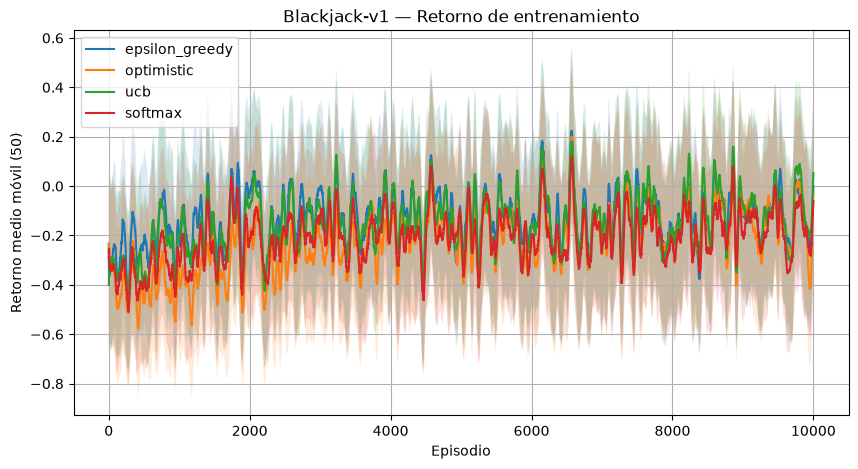

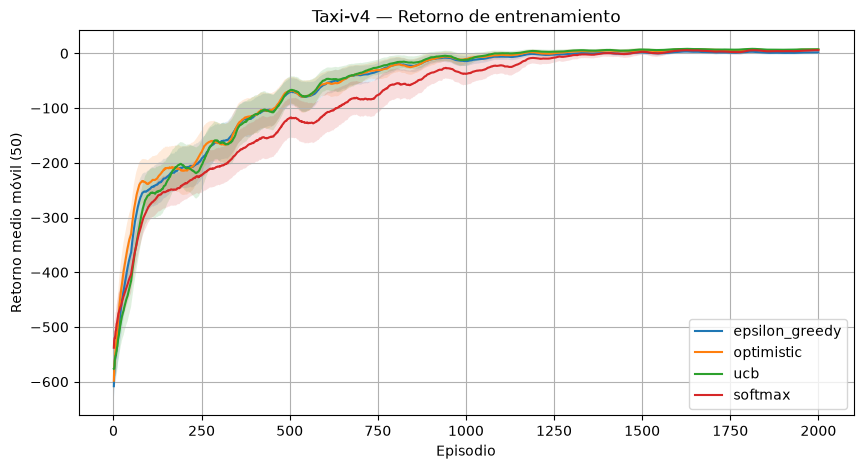

In [25]:
# ============================================================
# VISUALIZACIÓN 1 — RETORNO DE ENTRENAMIENTO
# ============================================================

window = 50

train_curve = (
    training_results
    .groupby(["env", "strategy", "episode"])["return"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

train_curve["se"] = (
    train_curve["std"] /
    np.sqrt(train_curve["count"])
)

train_curve["ci_low"] = (
    train_curve["mean"] - Z_95 * train_curve["se"]
)

train_curve["ci_high"] = (
    train_curve["mean"] + Z_95 * train_curve["se"]
)

# Media móvil después de calcular la curva entre corridas
train_curve["mean_smooth"] = (
    train_curve
    .groupby(["env", "strategy"])["mean"]
    .transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
)

train_curve["ci_low_smooth"] = (
    train_curve
    .groupby(["env", "strategy"])["ci_low"]
    .transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
)

train_curve["ci_high_smooth"] = (
    train_curve
    .groupby(["env", "strategy"])["ci_high"]
    .transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
)

for env_id in ENV_CONFIG:

    plt.figure(figsize=(10, 5))

    data_env = train_curve[
        train_curve["env"] == env_id
    ]

    for strategy in STRATEGIES:

        data = data_env[
            data_env["strategy"] == strategy
        ]

        plt.plot(
            data["episode"],
            data["mean_smooth"],
            label=strategy
        )

        plt.fill_between(
            data["episode"],
            data["ci_low_smooth"],
            data["ci_high_smooth"],
            alpha=0.15
        )

    plt.title(
        f"{env_id} — Retorno de entrenamiento"
    )
    plt.xlabel("Episodio")
    plt.ylabel("Retorno medio móvil (50)")
    plt.legend()
    plt.grid(True)
    plt.show()

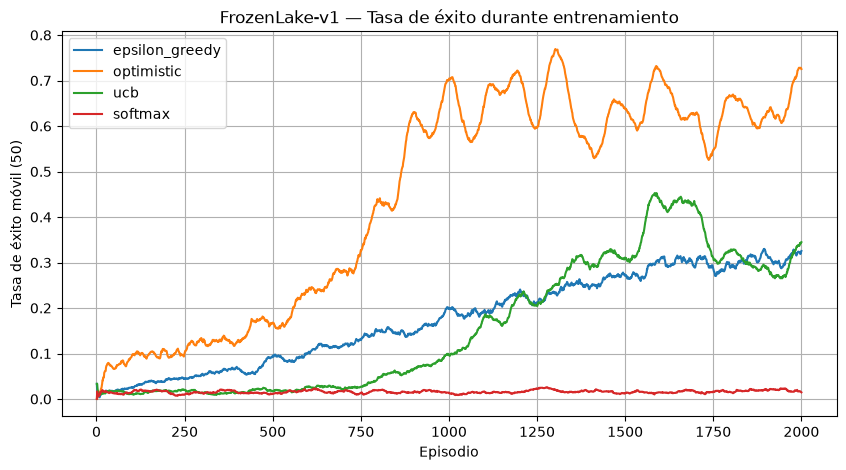

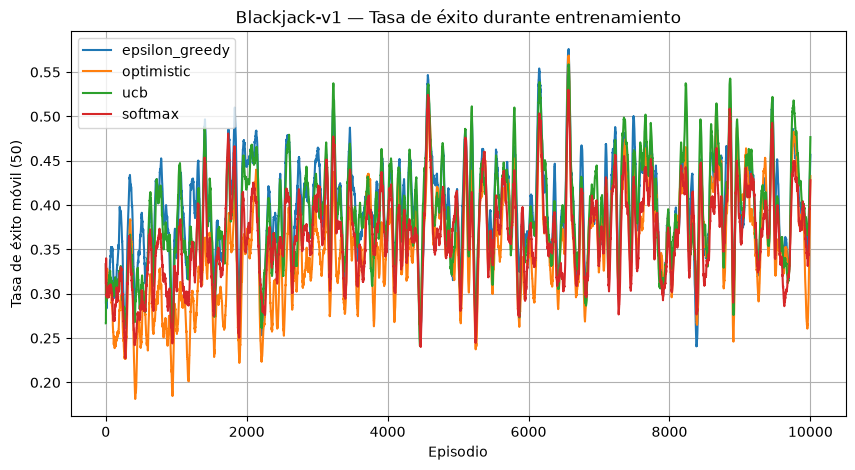

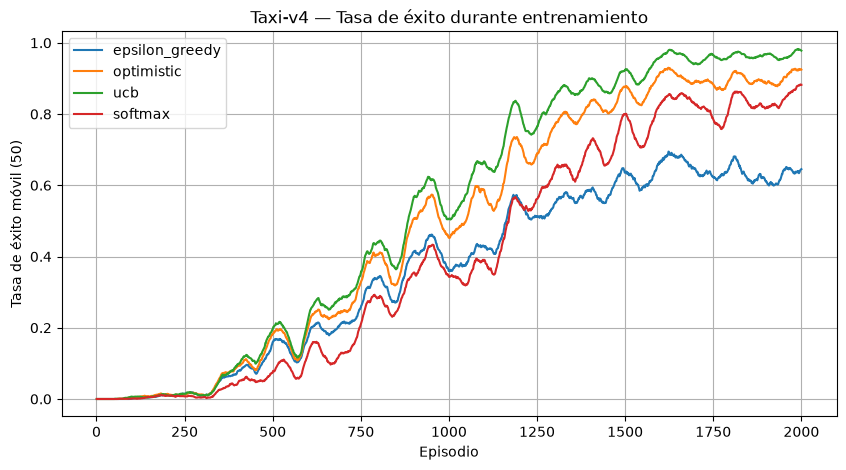

In [26]:
# ============================================================
# VISUALIZACIÓN 2 — ÉXITO
# ============================================================

success_curve = (
    training_results
    .groupby(["env", "strategy", "episode"])["success"]
    .mean()
    .reset_index(name="success")
)

success_curve["success_smooth"] = (
    success_curve
    .groupby(["env", "strategy"])["success"]
    .transform(
        lambda x: x.rolling(50, min_periods=1).mean()
    )
)

for env_id in ENV_CONFIG:

    plt.figure(figsize=(10, 5))

    data_env = success_curve[
        success_curve["env"] == env_id
    ]

    for strategy in STRATEGIES:

        data = data_env[
            data_env["strategy"] == strategy
        ]

        plt.plot(
            data["episode"],
            data["success_smooth"],
            label=strategy
        )

    plt.title(
        f"{env_id} — Tasa de éxito durante entrenamiento"
    )
    plt.xlabel("Episodio")
    plt.ylabel("Tasa de éxito móvil (50)")
    plt.legend()
    plt.grid(True)
    plt.show()

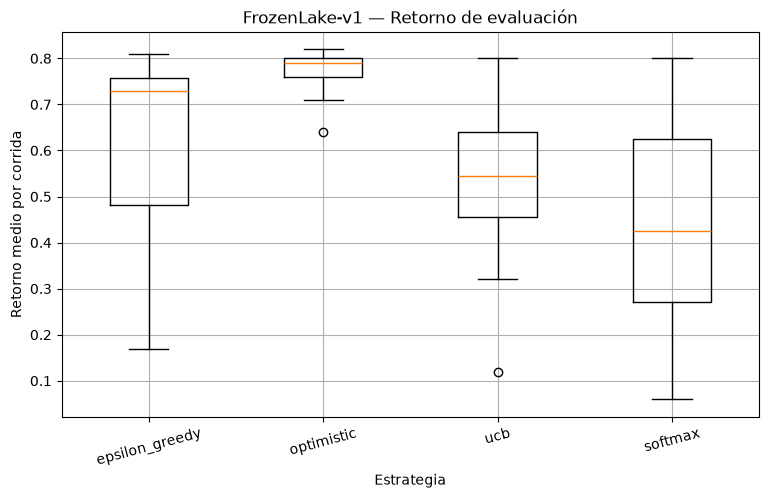

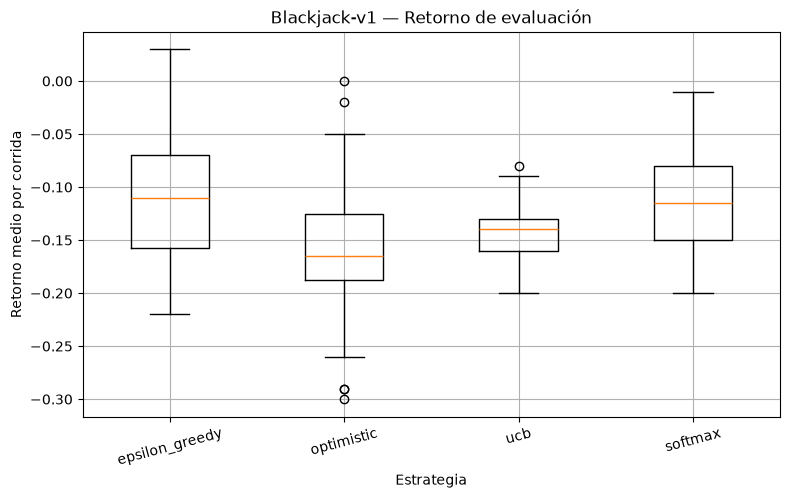

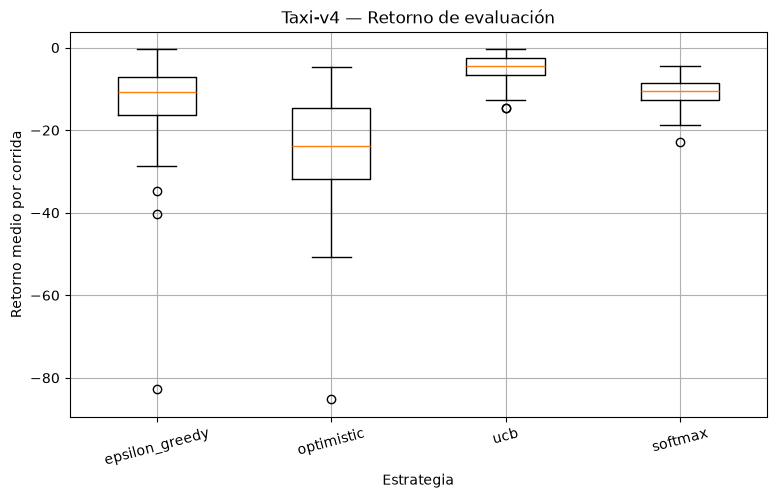

In [29]:
# ============================================================
# VISUALIZACIÓN 3 — RETORNO DE EVALUACIÓN
# ============================================================

for env_id in ENV_CONFIG:

    data_env = eval_run[
        eval_run["env"] == env_id
    ]

    plt.figure(figsize=(9, 5))

    data_to_plot = [
        data_env[
            data_env["strategy"] == strategy
        ]["eval_return"].to_numpy()
        for strategy in STRATEGIES
    ]

    plt.boxplot(
    data_to_plot,
    tick_labels=list(STRATEGIES.keys())
)

    plt.title(
        f"{env_id} — Retorno de evaluación"
    )
    plt.xlabel("Estrategia")
    plt.ylabel("Retorno medio por corrida")
    plt.xticks(rotation=15)
    plt.grid(True)
    plt.show()

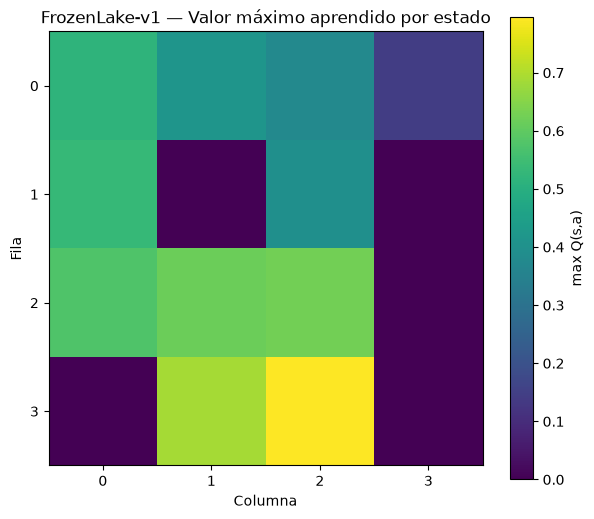

In [30]:
# ============================================================
# VISUALIZACIÓN 4 — HEATMAP max_a Q(s,a)
# ============================================================

q_heatmap, _, _ = train_q_learning(
    env_id="FrozenLake-v1",
    strategy="epsilon_greedy",
    episodes=ENV_CONFIG["FrozenLake-v1"]["episodes"],
    max_steps=ENV_CONFIG["FrozenLake-v1"]["max_steps"],
    alpha=0.10,
    gamma=0.99,
    seed=SEED,
    env_kwargs=ENV_CONFIG["FrozenLake-v1"]["kwargs"],
    **STRATEGIES["epsilon_greedy"],
)

max_q = np.max(q_heatmap, axis=1)

heatmap_values = max_q.reshape(4, 4)

plt.figure(figsize=(7, 6))

plt.imshow(heatmap_values)

plt.colorbar(label="max Q(s,a)")

plt.title(
    "FrozenLake-v1 — Valor máximo aprendido por estado"
)

plt.xlabel("Columna")
plt.ylabel("Fila")

plt.xticks(range(4))
plt.yticks(range(4))

plt.show()

## 9. Sensibilidad de hiperparámetros

Seleccione el entorno donde las estrategias difirieron más y compare:

| Estrategia | Valores mínimos |
|---|---|
| ε-greedy | ε ∈ {0.01, 0.10, 0.30} |
| Optimista | Q0 ∈ {1, 5, 10}, con ε = 0.01 |
| UCB | c ∈ {0.25, 1, 2} |
| Softmax | τ ∈ {0.10, 0.50, 1.0} |

Puede usar 10 corridas, pero mantenga constantes episodios, α, γ y semillas. Presente una gráfica o tabla y explique el patrón; no elija un valor mirando únicamente una corrida.


In [32]:
# TODO: ejecutar y analizar la sensibilidad.
# ============================================================
# 9. SENSIBILIDAD DE HIPERPARÁMETROS
# ============================================================

sensitivity_env = "FrozenLake-v1"

# Valores exigidos por el reto
sensitivity_values = {
    "epsilon_greedy": [0.01, 0.10, 0.30],
    "optimistic": [1.0, 5.0, 10.0],
    "ucb": [0.25, 1.0, 2.0],
    "softmax": [0.10, 0.50, 1.0],
}

N_SENS_RUNS = 10
SENS_BASE_SEED = 3026

episodes = ENV_CONFIG[sensitivity_env]["episodes"]
max_steps = ENV_CONFIG[sensitivity_env]["max_steps"]
env_kwargs = ENV_CONFIG[sensitivity_env]["kwargs"]

alpha = 0.10
gamma = 0.99

sensitivity_results = []

for strategy, values in sensitivity_values.items():

    for value in values:

        for run in range(N_SENS_RUNS):

            # Misma familia de semillas para todos
            # los valores del hiperparámetro.
            train_seed = SENS_BASE_SEED + run
            eval_seed = 2_000_000 + SENS_BASE_SEED + run

            # Parámetros base de la estrategia
            params = dict(STRATEGIES[strategy])

            # Sustituir únicamente el hiperparámetro analizado
            if strategy == "epsilon_greedy":
                params["epsilon"] = value

            elif strategy == "optimistic":
                params["q0"] = value

            elif strategy == "ucb":
                params["c"] = value

            elif strategy == "softmax":
                params["temperature"] = value

            # -------------------------
            # Entrenamiento
            # -------------------------
            q, history, counts = train_q_learning(
                env_id=sensitivity_env,
                strategy=strategy,
                episodes=episodes,
                max_steps=max_steps,
                alpha=alpha,
                gamma=gamma,
                seed=train_seed,
                env_kwargs=env_kwargs,
                **params,
            )

            # -------------------------
            # Evaluación
            # -------------------------
            evaluation = evaluate_policy(
                env_id=sensitivity_env,
                q=q,
                n_episodes=100,
                max_steps=max_steps,
                seed=eval_seed,
                env_kwargs=env_kwargs,
            )

            sensitivity_results.append({
                "env": sensitivity_env,
                "strategy": strategy,
                "value": value,
                "run": run,
                "eval_return": evaluation["return"].mean(),
                "eval_success": evaluation["success"].mean(),
                "eval_length": evaluation["length"].mean(),
            })


sensitivity_df = pd.DataFrame(sensitivity_results)

print("Filas generadas:", len(sensitivity_df))

display(sensitivity_df.head())

Filas generadas: 120


,env,strategy,value,run,eval_return,eval_success,eval_length
0,FrozenLake-v1,epsilon_greedy,0.01,0,0.01,0.01,6.06
1,FrozenLake-v1,epsilon_greedy,0.01,1,0.77,0.77,31.60
2,FrozenLake-v1,epsilon_greedy,0.01,2,0.13,0.13,25.36
3,FrozenLake-v1,epsilon_greedy,0.01,3,0.19,0.19,28.57
4,FrozenLake-v1,epsilon_greedy,0.01,4,0.10,0.10,30.67


In [33]:
sensitivity_summary = (
    sensitivity_df
    .groupby(["strategy", "value"])
    .agg(
        mean_return=("eval_return", "mean"),
        std_return=("eval_return", "std"),
        mean_success=("eval_success", "mean"),
        std_success=("eval_success", "std"),
        mean_length=("eval_length", "mean"),
        n_runs=("run", "count"),
    )
    .reset_index()
)

sensitivity_summary["ci95_low"] = (
    sensitivity_summary["mean_return"]
    - 1.96 * sensitivity_summary["std_return"]
    / np.sqrt(sensitivity_summary["n_runs"])
)

sensitivity_summary["ci95_high"] = (
    sensitivity_summary["mean_return"]
    + 1.96 * sensitivity_summary["std_return"]
    / np.sqrt(sensitivity_summary["n_runs"])
)

display(
    sensitivity_summary.style.format({
        "value": "{:.2f}",
        "mean_return": "{:.3f}",
        "std_return": "{:.3f}",
        "mean_success": "{:.3f}",
        "std_success": "{:.3f}",
        "mean_length": "{:.2f}",
        "ci95_low": "{:.3f}",
        "ci95_high": "{:.3f}",
    })
)

,strategy,value,mean_return,std_return,mean_success,std_success,mean_length,n_runs,ci95_low,ci95_high
0,epsilon_greedy,0.01,0.197,0.213,0.197,0.213,21.06,10,0.065,0.329
1,epsilon_greedy,0.10,0.592,0.265,0.592,0.265,33.33,10,0.428,0.756
2,epsilon_greedy,0.30,0.772,0.098,0.772,0.098,38.27,10,0.712,0.832
3,optimistic,1.00,0.830,0.008,0.830,0.008,37.64,10,0.825,0.835
4,optimistic,5.00,0.804,0.079,0.804,0.079,40.24,10,0.755,0.853
5,optimistic,10.00,0.830,0.008,0.830,0.008,37.69,10,0.825,0.835
6,softmax,0.10,0.610,0.189,0.610,0.189,35.64,10,0.493,0.727
7,softmax,0.50,0.506,0.157,0.506,0.157,30.25,10,0.409,0.603
8,softmax,1.00,0.478,0.219,0.478,0.219,30.52,10,0.342,0.614
9,ucb,0.25,0.545,0.112,0.545,0.112,33.54,10,0.475,0.615


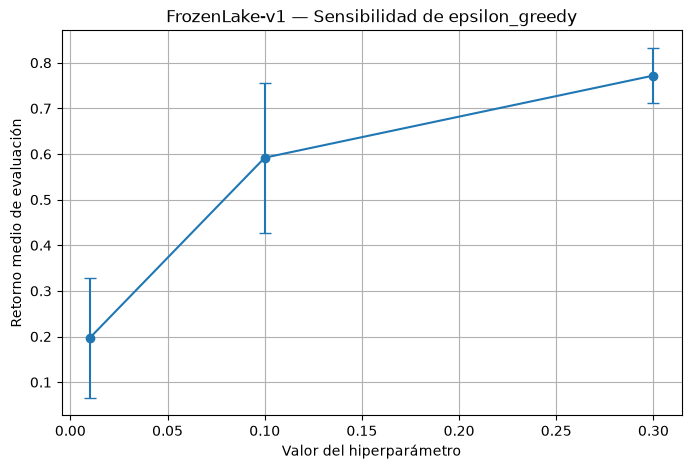

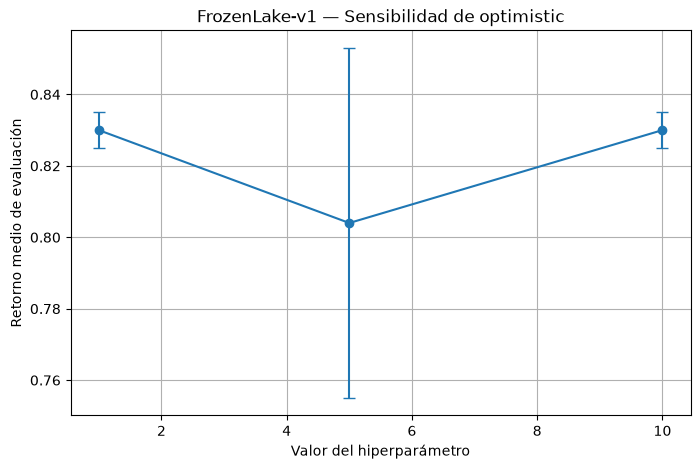

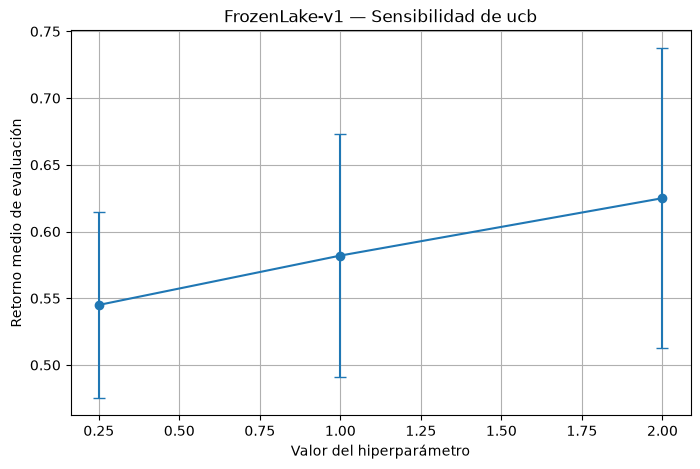

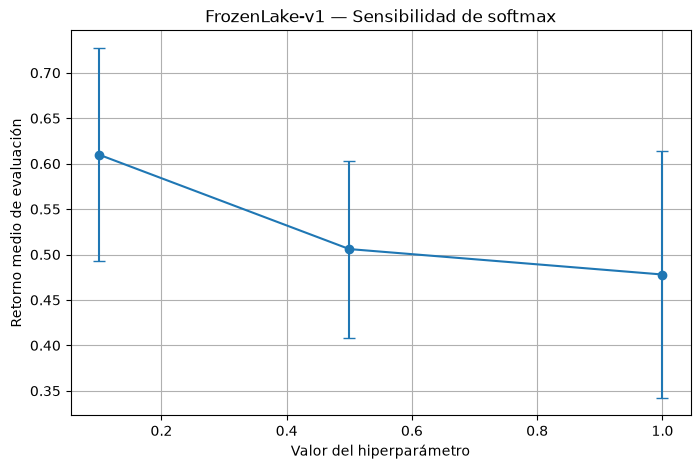

In [34]:
# Gráfica de sensibilidad
for strategy in sensitivity_values:

    data = sensitivity_summary[
        sensitivity_summary["strategy"] == strategy
    ].sort_values("value")

    plt.figure(figsize=(8, 5))

    plt.errorbar(
        data["value"],
        data["mean_return"],
        yerr=[
            data["mean_return"] - data["ci95_low"],
            data["ci95_high"] - data["mean_return"],
        ],
        marker="o",
        capsize=4,
    )

    plt.title(
        f"FrozenLake-v1 — Sensibilidad de {strategy}"
    )
    plt.xlabel("Valor del hiperparámetro")
    plt.ylabel("Retorno medio de evaluación")
    plt.grid(True)
    plt.show()

In [35]:
# Tabla informe
display(
    sensitivity_summary[
        [
            "strategy",
            "value",
            "mean_return",
            "ci95_low",
            "ci95_high",
            "mean_success",
            "mean_length",
        ]
    ]
)

,strategy,value,mean_return,ci95_low,ci95_high,mean_success,mean_length
0,epsilon_greedy,0.01,0.197,0.065291,0.328709,0.197,21.064
1,epsilon_greedy,0.10,0.592,0.427760,0.756240,0.592,33.331
2,epsilon_greedy,0.30,0.772,0.711568,0.832432,0.772,38.270
3,optimistic,1.00,0.830,0.824939,0.835061,0.830,37.637
4,optimistic,5.00,0.804,0.755004,0.852996,0.804,40.242
5,optimistic,10.00,0.830,0.824939,0.835061,0.830,37.687
6,softmax,0.10,0.610,0.492691,0.727309,0.610,35.638
7,softmax,0.50,0.506,0.408647,0.603353,0.506,30.252
8,softmax,1.00,0.478,0.342088,0.613912,0.478,30.525
9,ucb,0.25,0.545,0.475289,0.614711,0.545,33.540


## 10. Interpretación

Responda citando valores, tablas o figuras del notebook:




1. ¿Qué estrategia aprendió más rápido en cada entorno?

In [38]:
# ¿Qué estrategia alcanza primero un 50% de éxito móvil?
learning_speed = (
    training_results
    .sort_values(["env", "strategy", "run", "episode"])
    .copy()
)

learning_speed["success_ma50"] = (
    learning_speed
    .groupby(["env", "strategy", "run"])["success"]
    .transform(lambda x: x.rolling(50, min_periods=50).mean())
)

# Primer episodio en que cada corrida alcanza >= 50%
threshold = 0.50

first_reach = (
    learning_speed[learning_speed["success_ma50"] >= threshold]
    .groupby(["env", "strategy", "run"])["episode"]
    .min()
    .reset_index(name="first_episode_50_success")
)

# Resumen entre las 30 corridas
speed_summary = (
    first_reach
    .groupby(["env", "strategy"])
    .agg(
        episodio_mediano=("first_episode_50_success", "median"),
        episodio_promedio=("first_episode_50_success", "mean"),
        corridas_que_llegan=("first_episode_50_success", "count"),
    )
    .reset_index()
    .sort_values(["env", "episodio_mediano"])
)

display(speed_summary)

,env,strategy,episodio_mediano,episodio_promedio,corridas_que_llegan
0,Blackjack-v1,epsilon_greedy,360.5,501.033333,30
3,Blackjack-v1,ucb,907.0,952.866667,30
2,Blackjack-v1,softmax,1402.5,1412.866667,30
1,Blackjack-v1,optimistic,2138.0,2534.766667,30
5,FrozenLake-v1,optimistic,835.0,828.700000,30
6,FrozenLake-v1,ucb,1397.0,1397.769231,26
4,FrozenLake-v1,epsilon_greedy,1559.0,1454.882353,17
10,Taxi-v4,ucb,861.5,840.633333,30
8,Taxi-v4,optimistic,883.0,870.600000,30
7,Taxi-v4,epsilon_greedy,943.0,990.400000,30


Mirando el episodio mediano en el que la tasa de éxito móvil llegó al 50 %, la que aprendió más rápido fue diferente en cada entorno.

En Blackjack-v1, la más rápida fue ε-greedy, llegando a ese nivel alrededor del episodio 361 en la mediana de las 30 corridas. Después estuvo UCB con 907 episodios, Softmax con 1403 y Optimistic con 2138. O sea, acá ε-greedy fue bastante más rápida que las otras.

En FrozenLake-v1, la más rápida fue Optimistic, con una mediana de 835 episodios. UCB llegó alrededor del episodio 1397, mientras que ε-greedy lo hizo en 1559. En este caso hay que tener en cuenta que ε-greedy solo llegó al 50 % en 17 de las 30 corridas, y UCB en 26 de 30, mientras que Optimistic lo consiguió en las 30.

En Taxi-v4, la que aprendió más rápido fue UCB, con una mediana de 862 episodios, seguida muy cerca por Optimistic con 883. ε-greedy necesitó 943 episodios y Softmax fue la más lenta con 1145.

Entonces, si lo resumo: ε-greedy fue la más rápida en Blackjack, Optimistic en FrozenLake y UCB en Taxi. Me parece interesante porque no hay una estrategia que sea la más rápida en los tres entornos, sino que depende bastante de las características del entorno.

2. ¿La estrategia con mejor curva de entrenamiento produjo también la mejor política greedy?


In [39]:
# Comparación directa: curva de entrenamiento vs política greedy

# Promedio del retorno en el último 10% de episodios por entorno/estrategia
curve_vs_policy = (
    summary[
        [
            "env",
            "strategy",
            "train_return_last10",
            "train_auc",
            "eval_return",
            "eval_success_rate",
        ]
    ]
    .sort_values(["env", "train_return_last10"], ascending=[True, False])
)

display(curve_vs_policy)

,env,strategy,train_return_last10,train_auc,eval_return,eval_success_rate
2,Blackjack-v1,ucb,-0.102331,-1478.716667,-0.143000,0.378333
0,Blackjack-v1,epsilon_greedy,-0.110323,-1303.950000,-0.107000,0.391333
3,Blackjack-v1,optimistic,-0.151449,-2285.600000,-0.163333,0.369000
1,Blackjack-v1,softmax,-0.161938,-2068.900000,-0.110333,0.394667
4,FrozenLake-v1,optimistic,0.649420,901.766667,0.777667,0.777667
5,FrozenLake-v1,epsilon_greedy,0.313267,358.166667,0.615000,0.615000
6,FrozenLake-v1,ucb,0.300166,324.083333,0.550000,0.550000
7,FrozenLake-v1,softmax,0.019071,31.633333,0.450000,0.450000
8,Taxi-v4,ucb,7.036153,-104885.250000,-5.718000,0.934000
11,Taxi-v4,optimistic,6.176617,-99940.350000,-25.233000,0.882667


No necesariamente. Esto cambia dependiendo del entorno.

En Blackjack-v1, sí se mira que la mejor curva de entrenamiento fue la de ε-greedy, con un AUC de -1303.95, y también produjo la mejor política greedy, con un retorno de -0.107. En este caso sí coincidió, aunque la diferencia con Softmax (-0.110) es bastante pequeña.

En FrozenLake-v1 también se ve una coincidencia más clara: Optimistic tuvo el mejor AUC (901.77) y también obtuvo la mejor política greedy, con un retorno de evaluación de 0.778 y una tasa de éxito de 77.8 %.

En Taxi-v4 es donde más se nota que una buena curva de entrenamiento no necesariamente significa una mejor política final. Optimistic tuvo el mejor AUC (-99,940.4), pero la mejor política greedy fue UCB, con un retorno de -5.718 y una tasa de éxito de 93.4 %, frente a -25.233 y 88.3 % de Optimistic.

Entonces, no se puede asumir que la estrategia que tuvo la mejor curva durante el entrenamiento necesariamente termina produciendo la mejor política greedy. En Taxi se ve claramente esta diferencia. Para mí esto también muestra por qué es importante separar el desempeño durante el aprendizaje de la evaluación final de la política.

3. ¿Dónde ayudó y dónde perjudicó la inicialización optimista? Relaciónelo con recompensas negativas y estados poco visitados.

In [40]:

# Comparación final entre estrategias
optimistic_comparison = summary[
    [
        "env",
        "strategy",
        "train_return_last10",
        "train_auc",
        "eval_return",
        "eval_success_rate",
        "eval_length",
    ]
].sort_values(["env", "eval_return"], ascending=[True, False])

display(optimistic_comparison)

,env,strategy,train_return_last10,train_auc,eval_return,eval_success_rate,eval_length
0,Blackjack-v1,epsilon_greedy,-0.110323,-1303.950000,-0.107000,0.391333,1.566333
1,Blackjack-v1,softmax,-0.161938,-2068.900000,-0.110333,0.394667,1.483000
2,Blackjack-v1,ucb,-0.102331,-1478.716667,-0.143000,0.378333,1.471000
3,Blackjack-v1,optimistic,-0.151449,-2285.600000,-0.163333,0.369000,1.470333
4,FrozenLake-v1,optimistic,0.649420,901.766667,0.777667,0.777667,40.586000
5,FrozenLake-v1,epsilon_greedy,0.313267,358.166667,0.615000,0.615000,35.307000
6,FrozenLake-v1,ucb,0.300166,324.083333,0.550000,0.550000,44.240333
7,FrozenLake-v1,softmax,0.019071,31.633333,0.450000,0.450000,30.712667
8,Taxi-v4,ucb,7.036153,-104885.250000,-5.718000,0.934000,25.332000
9,Taxi-v4,softmax,4.591045,-148492.800000,-10.851667,0.909000,29.940667


In [41]:
# Retorno de entrenamiento de Optimistic por entorno
optimistic_training = (
    training_results[
        training_results["strategy"] == "optimistic"
    ]
    .groupby(["env", "episode"])
    .agg(
        mean_return=("return", "mean"),
        mean_length=("length", "mean"),
        mean_success=("success", "mean"),
    )
    .reset_index()
)

display(
    optimistic_training.groupby("env").agg(
        inicio_return=("mean_return", "first"),
        final_return=("mean_return", "last"),
        max_return=("mean_return", "max"),
        inicio_success=("mean_success", "first"),
        final_success=("mean_success", "last"),
    )
)

,inicio_return,final_return,max_return,inicio_success,final_success
env,,,,,
Blackjack-v1,-0.233333,0.166667,0.566667,0.333333,0.566667
FrozenLake-v1,0.000000,0.666667,0.900000,0.000000,0.666667
Taxi-v4,-598.200000,8.766667,9.333333,0.000000,0.966667


In [42]:
print("Forma de counts:", counts.shape)

print("\nVisitas por acción:")
display(pd.DataFrame(counts).describe())

print("\nAcciones nunca visitadas:")
print((counts == 0).sum())

Forma de counts: (16, 4)

Visitas por acción:


,0,1,2,3
count,16.00000,16.000000,16.000000,16.00000
mean,241.81250,246.062500,238.312500,240.25000
std,429.58495,427.253316,418.390682,427.08555
min,0.00000,0.000000,0.000000,0.00000
25%,0.00000,0.000000,0.000000,0.00000
50%,69.50000,63.000000,56.500000,55.50000
75%,232.00000,270.000000,256.500000,255.50000
max,1640.00000,1629.000000,1587.000000,1643.00000



Acciones nunca visitadas:
20


La inicialización optimista ayudó principalmente en FrozenLake-v1, donde obtuvo el mejor resultado de evaluación, con un retorno de 0.778 y una tasa de éxito de 77.8 %. Además, en la sensibilidad, los valores de Q0 de 1, 5 y 10 tuvieron resultados bastante similares, alrededor de 0.804–0.830, lo que muestra que la idea de empezar con valores altos sí favoreció la exploración en este entorno.

En cambio, perjudicó en Blackjack-v1 y especialmente en Taxi-v4. En Blackjack, Optimistic tuvo un retorno de -0.163, peor que ε-greedy (-0.107) y Softmax (-0.110). En Taxi la diferencia fue mucho más grande: obtuvo -25.233, mientras que UCB llegó a -5.718. También tuvo una tasa de éxito menor (88.3 %) que UCB (93.4 %).

Esto se puede relacionar con que la inicialización optimista hace que los estados y acciones poco visitados tengan inicialmente valores altos, por lo que el agente tiene un incentivo para explorarlos. En FrozenLake, esta exploración parece haber ayudado a descubrir mejores caminos y a salir de estados que inicialmente podían tener pocas visitas. Pero en Blackjack y Taxi, donde existen muchas recompensas negativas o penalizaciones por tomar pasos/acciones, mantener valores iniciales altos puede hacer que el agente explore demasiado y tarde más en aprender cuáles acciones realmente son convenientes. En Taxi esto se nota bastante, porque Optimistic terminó con trayectorias más largas (34.77 pasos) que UCB (25.33).

Entonces, la inicialización optimista ayudó cuando la exploración adicional permitió descubrir mejores acciones, como en FrozenLake, pero perjudicó cuando esa exploración sobre estados poco visitados tenía un costo alto por las recompensas negativas y las penalizaciones del entorno, especialmente en Taxi.

4. ¿Cómo se comportó UCB cuando muchos pares estado–acción fueron visitados pocas veces?

In [43]:

ucb_results = summary[
    summary["strategy"] == "ucb"
][
    [
        "env",
        "train_return_last10",
        "train_auc",
        "eval_return",
        "eval_success_rate",
        "eval_length",
    ]
]

display(ucb_results)

,env,train_return_last10,train_auc,eval_return,eval_success_rate,eval_length
2,Blackjack-v1,-0.102331,-1478.716667,-0.143,0.378333,1.471000
6,FrozenLake-v1,0.300166,324.083333,0.550,0.550000,44.240333
8,Taxi-v4,7.036153,-104885.250000,-5.718,0.934000,25.332000


In [44]:

q_ucb, history_ucb, counts_ucb = train_q_learning(
    env_id="FrozenLake-v1",
    strategy="ucb",
    episodes=ENV_CONFIG["FrozenLake-v1"]["episodes"],
    max_steps=ENV_CONFIG["FrozenLake-v1"]["max_steps"],
    alpha=0.10,
    gamma=0.99,
    seed=2026,
    env_kwargs=ENV_CONFIG["FrozenLake-v1"]["kwargs"],
    **STRATEGIES["ucb"],
)

print("Forma counts:", counts_ucb.shape)

print("\nPares estado-acción nunca visitados:")
print((counts_ucb == 0).sum())

print("\nPares visitados 1 vez:")
print((counts_ucb == 1).sum())

print("\nPares visitados 5 veces o menos:")
print((counts_ucb <= 5).sum())

print("\nTotal de pares estado-acción:")
print(counts_ucb.size)

print("\nResumen de visitas:")
display(pd.DataFrame(counts_ucb).stack().describe())

Forma counts: (16, 4)

Pares estado-acción nunca visitados:
20

Pares visitados 1 vez:
0

Pares visitados 5 veces o menos:
20

Total de pares estado-acción:
64

Resumen de visitas:


count      64.000000
mean      782.453125
std      1902.088025
min         0.000000
25%         0.000000
50%       123.000000
75%       384.750000
max      9081.000000
dtype: float64

Los datos muestran que UCB sí tuvo una cantidad importante de pares estado–acción poco visitados. En la corrida de FrozenLake-v1, de los 64 pares estado–acción, 20 nunca fueron visitados, es decir, aproximadamente el 31.25 %. Además, no hubo pares visitados solamente 1 vez, pero esos mismos 20 pares quedaron con 5 visitas o menos. Esto muestra que las visitas estuvieron bastante concentradas en algunos pares: la mediana fue de 123 visitas, mientras que el máximo llegó a 9081.

A pesar de esto, UCB tuvo un desempeño razonable en FrozenLake, con un retorno de evaluación de 0.550 y una tasa de éxito de 55 %. Sin embargo, quedó por debajo de Optimistic, que obtuvo 0.778 de retorno y 77.8 % de éxito.

Esto tiene sentido con el funcionamiento de UCB, porque la estrategia da prioridad a acciones que han sido poco visitadas. En este caso sí había muchos pares sin visitar, pero eso no significa que todos terminaran siendo explorados; algunos quedaron sin visitas incluso después del entrenamiento. Entonces, UCB sí favoreció la exploración de acciones poco conocidas, pero la exploración no fue suficiente para cubrir todos los pares estado–acción.

En general, los datos muestran que UCB pudo aprovechar bastante bien las acciones que sí fueron visitadas, pero en FrozenLake todavía quedaron 20 de 64 pares sin explorar, y su desempeño final fue inferior al de la inicialización optimista.

5. ¿Qué efecto tuvo la temperatura de Softmax sobre estabilidad y desempeño?

In [45]:
# ============================================================
# DATOS — EFECTO DE LA TEMPERATURA EN SOFTMAX
# ============================================================

softmax_sensitivity = sensitivity_summary[
    sensitivity_summary["strategy"] == "softmax"
][
    [
        "value",
        "mean_return",
        "std_return",
        "ci95_low",
        "ci95_high",
        "mean_success",
        "std_success",
        "mean_length",
        "n_runs",
    ]
].sort_values("value")

display(
    softmax_sensitivity.style.format({
        "value": "{:.2f}",
        "mean_return": "{:.3f}",
        "std_return": "{:.3f}",
        "ci95_low": "{:.3f}",
        "ci95_high": "{:.3f}",
        "mean_success": "{:.3f}",
        "std_success": "{:.3f}",
        "mean_length": "{:.2f}",
    })
)

,value,mean_return,std_return,ci95_low,ci95_high,mean_success,std_success,mean_length,n_runs
6,0.10,0.610,0.189,0.493,0.727,0.610,0.189,35.64,10
7,0.50,0.506,0.157,0.409,0.603,0.506,0.157,30.25,10
8,1.00,0.478,0.219,0.342,0.614,0.478,0.219,30.52,10


In [46]:
# Softmax en los tres entornos
display(
    summary[
        summary["strategy"] == "softmax"
    ][
        [
            "env",
            "train_return_last10",
            "train_auc",
            "eval_return",
            "eval_success_rate",
            "eval_length",
            "ci95_low",
            "ci95_high",
        ]
    ]
)

,env,train_return_last10,train_auc,eval_return,eval_success_rate,eval_length,ci95_low,ci95_high
1,Blackjack-v1,-0.161938,-2068.900000,-0.110333,0.394667,1.483000,-0.129022,-0.091645
7,FrozenLake-v1,0.019071,31.633333,0.450000,0.450000,30.712667,0.371218,0.528782
9,Taxi-v4,4.591045,-148492.800000,-10.851667,0.909000,29.940667,-12.409518,-9.293815



Los datos de sensibilidad muestran que, en FrozenLake-v1, la temperatura sí tuvo un efecto sobre el desempeño. Con τ = 0.10 se obtuvo el mejor retorno medio (0.610) y una tasa de éxito de 61.0 %. Al subir la temperatura a 0.50, el retorno bajó a 0.506, y con τ = 1.00 bajó todavía más, hasta 0.478. Entonces, en este caso, las temperaturas más altas perjudicaron el desempeño.

En cuanto a la estabilidad, τ = 0.50 fue la que presentó la menor desviación estándar del retorno (0.157), seguida de τ = 0.10 (0.189). τ = 1.00 tuvo la mayor variabilidad, con una desviación de 0.219. Además, los IC también muestran que τ = 1.00 tuvo un rango bastante amplio ([0.342, 0.614]).

Entonces, en este experimento, una temperatura baja favoreció el desempeño, pero no necesariamente fue la más estable. τ = 0.10 obtuvo el mejor retorno y éxito, mientras que τ = 0.50 fue la más estable de las tres. Al aumentar demasiado la temperatura, la selección de acciones se vuelve más dispersa y en este caso terminó afectando tanto el desempeño como la estabilidad.

6. ¿Qué estrategia fue más sensible a la estocasticidad de FrozenLake?

In [47]:
# ============================================================
# DATOS — SENSIBILIDAD A LA ESTOCASTICIDAD EN FROZENLAKE
# ============================================================

frozenlake_variability = (
    eval_run[
        eval_run["env"] == "FrozenLake-v1"
    ]
    .groupby("strategy")
    .agg(
        mean_return=("eval_return", "mean"),
        std_return=("eval_return", "std"),
        mean_success=("eval_success", "mean"),
        std_success=("eval_success", "std"),
        mean_length=("eval_length", "mean"),
        std_length=("eval_length", "std"),
        n_runs=("run", "count"),
    )
    .reset_index()
)

frozenlake_variability["cv_return"] = (
    frozenlake_variability["std_return"].abs()
    / frozenlake_variability["mean_return"].abs()
)

display(
    frozenlake_variability.sort_values(
        "std_return",
        ascending=False
    ).style.format({
        "mean_return": "{:.3f}",
        "std_return": "{:.3f}",
        "mean_success": "{:.3f}",
        "std_success": "{:.3f}",
        "mean_length": "{:.2f}",
        "std_length": "{:.2f}",
        "cv_return": "{:.3f}",
    })
)

,strategy,mean_return,std_return,mean_success,std_success,mean_length,std_length,n_runs,cv_return
2,softmax,0.450,0.220,0.450,0.220,30.71,8.10,30,0.489
0,epsilon_greedy,0.615,0.193,0.615,0.193,35.31,4.43,30,0.313
3,ucb,0.550,0.150,0.550,0.150,44.24,13.32,30,0.273
1,optimistic,0.778,0.036,0.778,0.036,40.59,1.05,30,0.047


In [48]:
# Retorno de evaluación por corrida
frozenlake_runs = (
    eval_run[
        eval_run["env"] == "FrozenLake-v1"
    ]
    .groupby("strategy")["eval_return"]
    .agg(["min", "max", "mean", "std"])
    .reset_index()
)

display(
    frozenlake_runs.style.format({
        "min": "{:.3f}",
        "max": "{:.3f}",
        "mean": "{:.3f}",
        "std": "{:.3f}",
    })
)

,strategy,min,max,mean,std
0,epsilon_greedy,0.170,0.810,0.615,0.193
1,optimistic,0.640,0.820,0.778,0.036
2,softmax,0.060,0.800,0.450,0.220
3,ucb,0.120,0.800,0.550,0.150



La estrategia que mostró mayor sensibilidad fue Softmax. En las 30 corridas tuvo una desviación estándar del retorno de 0.220, la más alta de las cuatro estrategias. Además, sus resultados estuvieron entre 0.060 y 0.800, lo que muestra una variación bastante grande entre corridas.

ε-greedy también presentó cierta variabilidad, con una desviación de 0.193 y retornos entre 0.170 y 0.810. UCB fue un poco más estable, con una desviación de 0.150. La que menos variación tuvo fue Optimistic, con una desviación de solo 0.036 y resultados entre 0.640 y 0.820.

Esto también se ve en el coeficiente de variación: Softmax tuvo 0.489, frente a 0.313 de ε-greedy, 0.273 de UCB y solamente 0.047 de Optimistic.

Por lo tanto, Softmax fue la más sensible a la estocasticidad de FrozenLake, mientras que Optimistic fue claramente la más estable entre las 30 corridas. Esto muestra que la aleatoriedad del entorno afectó mucho más los resultados de Softmax que los de las otras estrategias.

7. En Blackjack, ¿qué diferencias aparecen entre manos con y sin as utilizable?


In [55]:
def evaluate_blackjack_by_ace(
    q,
    n_episodes,
    max_steps,
    seed,
    env_kwargs=None
):
    env = gym.make("Blackjack-v1", **(env_kwargs or {}))
    rng = np.random.default_rng(seed)

    rows = []

    try:
        for episode in range(n_episodes):

            obs, info = env.reset(
                seed=int(rng.integers(0, 2**31 - 1))
            )

            # 1 = tiene as utilizable, 0 = no tiene as utilizable
            initial_usable_ace = int(obs[2])

            total_return = 0.0
            length = 0

            for _ in range(max_steps):

                state = encode_observation(
                    obs,
                    env.observation_space
                )

                action = random_argmax(
                    q[state],
                    rng=rng
                )

                obs, reward, terminated, truncated, info = env.step(action)

                # Convertimos explícitamente la recompensa a float
                total_return += float(reward)

                length += 1

                if terminated or truncated:
                    break

            rows.append({
                "usable_ace": initial_usable_ace,
                "return": total_return,
                "length": length,
                "success": float(total_return > 0),
            })

    finally:
        env.close()

    return pd.DataFrame(rows)

In [56]:
# ============================================================
# IMPLEMENTACIÓN — BLACKJACK: AS UTILIZABLE VS NO UTILIZABLE
# ============================================================

blackjack_ace_results = []

for strategy in STRATEGIES:

    print(f"Entrenando estrategia: {strategy}")

    for run in range(N_RUNS):

        # -------------------------
        # Entrenamiento
        # -------------------------
        q, history, counts = train_q_learning(
            env_id="Blackjack-v1",
            strategy=strategy,
            episodes=ENV_CONFIG["Blackjack-v1"]["episodes"],
            max_steps=ENV_CONFIG["Blackjack-v1"]["max_steps"],
            alpha=0.10,
            gamma=0.99,
            seed=SEED + run,
            env_kwargs=ENV_CONFIG["Blackjack-v1"]["kwargs"],
            **STRATEGIES[strategy],
        )

        # -------------------------
        # Evaluación separada
        # -------------------------
        ace_data = evaluate_blackjack_by_ace(
            q=q,
            n_episodes=100,
            max_steps=ENV_CONFIG["Blackjack-v1"]["max_steps"],
            seed=1_000_000 + SEED + run,
            env_kwargs=ENV_CONFIG["Blackjack-v1"]["kwargs"],
        )

        ace_data["strategy"] = strategy
        ace_data["run"] = run

        blackjack_ace_results.append(ace_data)


# Unimos todas las corridas
blackjack_ace_results = pd.concat(
    blackjack_ace_results,
    ignore_index=True
)


# ============================================================
# RESUMEN POR ESTRATEGIA Y TIPO DE MANO
# ============================================================

blackjack_ace_summary = (
    blackjack_ace_results
    .groupby(["strategy", "usable_ace"])
    .agg(
        mean_return=("return", "mean"),
        std_return=("return", "std"),
        success_rate=("success", "mean"),
        mean_length=("length", "mean"),
        n=("return", "count"),
    )
    .reset_index()
)

display(
    blackjack_ace_summary.style.format({
        "mean_return": "{:.3f}",
        "std_return": "{:.3f}",
        "success_rate": "{:.3f}",
        "mean_length": "{:.2f}",
    })
)

Entrenando estrategia: epsilon_greedy
Entrenando estrategia: optimistic
Entrenando estrategia: ucb
Entrenando estrategia: softmax


,strategy,usable_ace,mean_return,std_return,success_rate,mean_length,n
0,epsilon_greedy,0,-0.158,0.941,0.376,1.51,2524
1,epsilon_greedy,1,0.345,0.906,0.641,1.61,476
2,optimistic,0,-0.184,0.942,0.369,1.42,2524
3,optimistic,1,0.208,0.950,0.576,1.68,476
4,softmax,0,-0.146,0.945,0.384,1.48,2524
5,softmax,1,0.359,0.899,0.647,1.58,476
6,ucb,0,-0.144,0.943,0.383,1.50,2524
7,ucb,1,0.374,0.889,0.651,1.55,476


Sí se ve una diferencia bastante clara entre las manos con y sin as utilizable. En las cuatro estrategias, las manos con as utilizable tuvieron un mejor desempeño.

Por ejemplo, con ε-greedy, el retorno medio pasó de -0.158 sin as utilizable a 0.345 con as utilizable, y la tasa de éxito pasó de 37.6 % a 64.1 %. Con UCB pasó algo parecido: el retorno fue de -0.144 sin as a 0.374 con as, mientras que el éxito aumentó de 38.3 % a 65.1 %.

También ocurrió con Softmax, donde el retorno pasó de -0.146 a 0.359 y el éxito de 38.4 % a 64.7 %. En Optimistic, el retorno pasó de -0.184 a 0.208, y el éxito de 36.9 % a 57.6 %.

Entonces, en los datos sí se ve que tener un as utilizable favoreció bastante el desempeño de la política greedy, independientemente de la estrategia utilizada. Sin as utilizable, todas las estrategias tuvieron retornos medios negativos y tasas de éxito menores al 40 %. Con as utilizable, todas pasaron a retornos positivos y tasas de éxito superiores al 57 %.

También se ve una pequeña diferencia en la longitud de las manos: con as utilizable las partidas fueron un poco más largas. Por ejemplo, en UCB fueron 1.50 pasos sin as frente a 1.55 con as, y en Optimistic 1.42 frente a 1.68. Esto podría estar relacionado con que el as utilizable da más margen para tomar acciones antes de terminar la mano

8. ¿Existe una estrategia ganadora para los tres escenarios y todas las métricas?


In [57]:
# ============================================================
# DATOS — ¿EXISTE UNA ESTRATEGIA GANADORA GLOBAL?
# ============================================================

metrics = [
    "train_return_last10",
    "train_auc",
    "eval_success_rate",
    "eval_return",
    "eval_length"
]

for env_id in summary["env"].unique():

    print(f"\n{'='*60}")
    print(env_id)
    print(f"{'='*60}")

    data_env = summary[summary["env"] == env_id].copy()

    print("\nMejor retorno final de entrenamiento:")
    display(
        data_env[
            ["strategy", "train_return_last10"]
        ].sort_values(
            "train_return_last10",
            ascending=False
        )
    )

    print("\nMejor AUC de entrenamiento:")
    display(
        data_env[
            ["strategy", "train_auc"]
        ].sort_values(
            "train_auc",
            ascending=False
        )
    )

    print("\nMejor tasa de éxito en evaluación:")
    display(
        data_env[
            ["strategy", "eval_success_rate"]
        ].sort_values(
            "eval_success_rate",
            ascending=False
        )
    )

    print("\nMejor retorno de evaluación:")
    display(
        data_env[
            ["strategy", "eval_return"]
        ].sort_values(
            "eval_return",
            ascending=False
        )
    )

    print("\nMenor longitud de evaluación:")
    display(
        data_env[
            ["strategy", "eval_length"]
        ].sort_values(
            "eval_length",
            ascending=True
        )
    )


Blackjack-v1

Mejor retorno final de entrenamiento:


,strategy,train_return_last10
2,ucb,-0.102331
0,epsilon_greedy,-0.110323
3,optimistic,-0.151449
1,softmax,-0.161938



Mejor AUC de entrenamiento:


,strategy,train_auc
0,epsilon_greedy,-1303.950000
2,ucb,-1478.716667
1,softmax,-2068.900000
3,optimistic,-2285.600000



Mejor tasa de éxito en evaluación:


...

,strategy,eval_success_rate
8,ucb,0.934000
10,epsilon_greedy,0.915333
9,softmax,0.909000
11,optimistic,0.882667



Mejor retorno de evaluación:


,strategy,eval_return
8,ucb,-5.718000
9,softmax,-10.851667
10,epsilon_greedy,-16.143333
11,optimistic,-25.233000



Menor longitud de evaluación:


,strategy,eval_length
8,ucb,25.332000
10,epsilon_greedy,28.765333
9,softmax,29.940667
11,optimistic,34.769000


9. Si el costo de interacción fuera alto, ¿qué estrategia recomendaría y por qué?


10. Mencione dos amenazas a la validez del experimento.

## 11. Uso de inteligencia artificial

**Herramienta(s):**  
**Prompts principales:**  
1. TODO  
2. TODO  

**Sugerencias aceptadas o rechazadas y por qué:** TODO  
**Cambios manuales:** TODO  
**Cómo se verificó el código y la interpretación:** TODO


## 12. Conclusiones

Redacte entre cuatro y seis conclusiones sustentadas en resultados. Evite repetir definiciones o afirmar causalidad sin evidencia.

1. TODO
2. TODO
3. TODO
4. TODO


## Lista de verificación de entrega

- [ ] Implementé y validé las cuatro estrategias.
- [ ] Q-Learning trata correctamente estados terminales y truncamientos.
- [ ] Comparé tres entornos con semillas y presupuesto equivalentes.
- [ ] Separé entrenamiento y evaluación greedy.
- [ ] Reporté variabilidad entre corridas.
- [ ] Incluí tabla, cuatro visualizaciones y sensibilidad.
- [ ] Respondí todas las preguntas con evidencia.
- [ ] Documenté el uso de IA y escribí conclusiones.
- [ ] Reinicié el kernel y ejecuté todas las celdas.
- [ ] Exporté y revisé el HTML.
